In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import errno
import os
import sys

from skimage import io

from im_reduction import *

In [2]:
# import image, background 
path_to_images= '/home/sara/Documents/SECAR/Diagnostics/Viewer-Image-Analysis/images/stability_FP2/originals'  
bg= io.imread(path_to_images+'/D1568_8_28_19_overnight_stability_056_BG.tiff')        

raw_image = io.imread(path_to_images+'/D1568_8_28_19_overnight_stability_043.tiff')  

In [3]:
image=Image(raw_image)
image.subtract_bg(bg)

Subtracting background...


array([[ 25,  -4, -23, ..., -35,  -3,  11],
       [  4,  -7,  18, ...,   5,  15,   0],
       [-13,  -7,  12, ...,  -7,   3,  21],
       ...,
       [  1,  15,  -3, ...,   6, -51,  20],
       [-10,  -9,  -1, ..., -34,   4,  23],
       [ 20, -24, -29, ...,  23,  20, -17]])

In [4]:
def get_profile(im_v, error):
    
    print("Getting y-axis profile...")
      #PROFILE IN Y
    profy = []
    profx = []
    errx = []
    erry = []
    for i in range(im_v.shape[0]): #loop over all y
        sum=0
        err=0
        for j in range(im_v.shape[1]): #loop over all x for each y: gives one number
            sum=sum + im_v[i][j]
            err = err + (error[i][j])**2
        profy.append(sum)
        erry.append(np.sqrt(err))
    offset_y = np.mean(profy[650:700])
    #profy = profy - offset_y

    
   
      #PROFILE IN X
    print("Getting x-axis profile...")
    for i in range(im_v.shape[1]): #loop over all x
        sum=0
        err=0
        for j in range(im_v.shape[0]): #loop over all y for each x: gives one number
            sum=sum + im_v[j][i]
            err = err + (error[j][i])**2
        profx.append(sum)
        errx.append(np.sqrt(err))
    offset_x = np.mean(profx[1:15])
    #profx = profx - offset_x
    
    return profx, profy, errx, erry

In [5]:
rprof_x, rprof_y, rerr_x, rerr_y = get_profile(image.raw, np.sqrt(image.raw))
prof_x, prof_y, err_x, err_y = get_profile(image.subtracted_data, image.error)

Getting y-axis profile...
Getting x-axis profile...
Getting y-axis profile...
Getting x-axis profile...


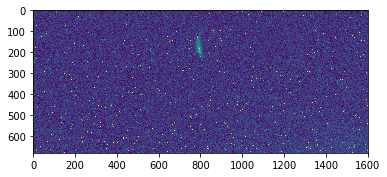

In [6]:
plt.imshow(image.raw)


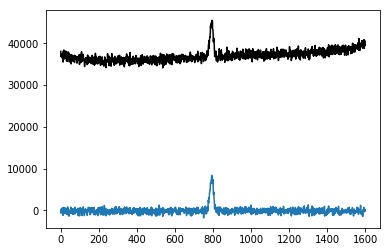

In [7]:
plt.plot(rprof_x, color='black')
plt.plot(prof_x)

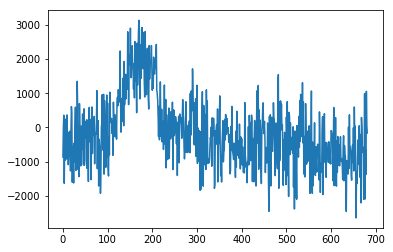

In [8]:
#plt.plot(rprof_y, color='black')
plt.plot(prof_y)

In [9]:
y = np.arange(image.y_size)
x = np.arange(image.x_size)

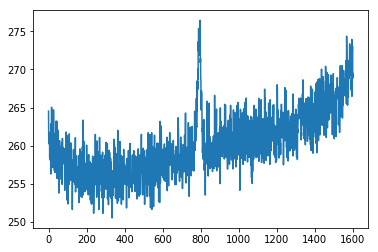

In [10]:
plt.plot(err_x)
#plt.plot(prof_x)

In [11]:
def profStats(prof, prof_err, xx):
    
    #run MC sim to sample a distribution of mean and std
    print("Calculating profile statistics...")
    i = 0
    iter_num = 1000
    xmc_data = [0 for i in range(0,iter_num)]
    
    while(i<iter_num):
        xmc_data[i] = np.random.normal(prof, prof_err)
        i = i + 1

    #get mean and std of each of the sampled distributions
    xmc_mean = [0 for i in range(0,iter_num)]
    xmc_mean_err= [0 for i in range(0,iter_num)]
    xmc_std = [0 for i in range(0,iter_num)]
    xmc_std_err = [0 for i in range(0,iter_num)]


    for k in range(0, iter_num):
        xmc_mean[k] = findMean(xx, xmc_data[k])
        xmc_std[k] = findSTD(xx, xmc_data[k], xmc_mean[k])

    xmc_mean = np.array(xmc_mean)
    xmc_std = np.array(xmc_std)

    #calculate the mean and the std (non-weighted) of the result
    avg_mean = np.mean(xmc_mean)
    std_mean = np.std(xmc_mean)

    avg_std = np.mean(xmc_std)
    std_std = np.std(xmc_std)
    
    #######plot distribution from MC#######

    fig, axs = plt.subplots(nrows=1, ncols=2)
    ax = axs[0]
    ax1= axs[1]

    ax.plot(xmc_mean, marker='.', linewidth=0)
    ax1.hist(xmc_mean, bins=100)
    #ax1.xaxis.set_ticks(np.arange(263, 263.7, 0.2))

    ax1.set_xlabel("Pixel")
    ax1.set_ylabel("Counts")
    ax1.set_title("Histogram of Mean Samples")
    ax.set_ylabel("Pixels")
    ax.set_xlabel("Iteration Number")
    ax.set_title("Mean Distribution For All Iterations")

    plt.tight_layout()
    
    ###################################
    
    #return the mean of the means, the error on the mean
    #and the mean of the stds and the error on that
    return avg_mean, std_mean, avg_std, std_std, xmc_data


def findMean(xx, prof):
    avg_x = []
    norm = []

    #weighted sum to get weighted average
    avg_x = np.sum(xx*prof)
    #sum of counts
    norm = np.sum(prof)

    avg = avg_x/norm

    return avg

def findSTD(xx, prof, avg):
    #prof = prof[int(avg-100):int(avg+100)]
    #xx = xx[int(avg-100):int(avg+100)]

    mean_diff = 0
    weighted_diff = 0
    norm = 0

    mean_diff = (xx - avg)**2
    weighted_diff = np.abs(np.sum(prof*mean_diff))
    norm = np.abs(np.sum(prof))
    
    std = np.sqrt(weighted_diff/(norm*(1-1/len(prof))))
    
    return std

Calculating profile statistics...
Calculating profile statistics...


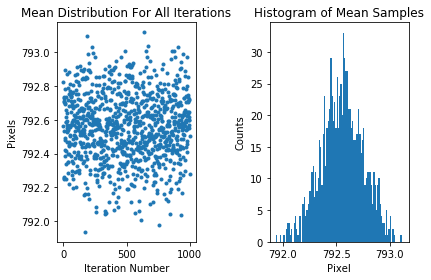

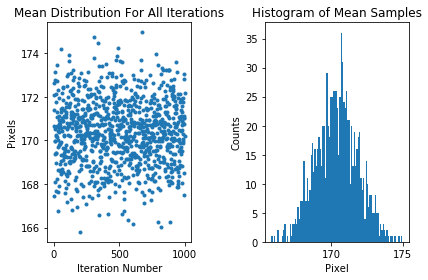

In [12]:
x_mean, x_mean_err, x_std, x_std_err, xmc_x = profStats(prof_x[760:820], err_x[760:820], x[760:820])
y_mean, y_mean_err, y_std, y_std_err, xmc_y = profStats(prof_y[100:250], err_y[100:250], y[100:250])

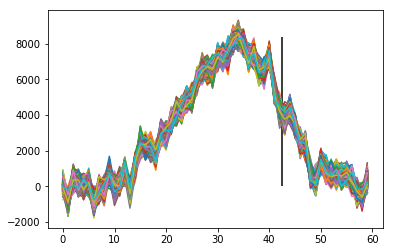

In [13]:
#plt.plot(prof_x)
for i in range (0, len(xmc_x)):
    plt.plot(xmc_x[i])
    
plt.vlines(x_mean-750, 0, max(prof_x))


In [14]:
mean_test= findMean(prof_y, y)
print(mean_test)

-374.9422791220432


(0, 150)

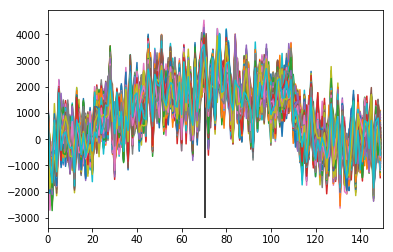

In [15]:
for i in range (0, len(xmc_y)):
    plt.plot(xmc_y[i])

plt.vlines(y_mean-100, -3000, max(prof_y))

plt.xlim(0,150)

In [16]:
data = prof_x
bins = np.linspace(0, 1600, 50)
digitized = np.digitize(data, bins)
bin_means = (np.histogram(data, bins, weights=data)[0] /
             np.histogram(data, bins)[0])

(400, 1200)

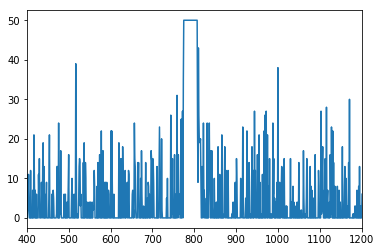

In [17]:
plt.plot(digitized)
plt.xlim(400, 1200)

(0, 680)

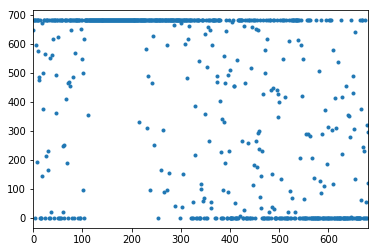

In [200]:
data = prof_y
bins = np.linspace(0, 682, 682)
digitized = np.digitize(data, bins)
bin_means = (np.histogram(data, bins, weights=data)[0] /
             np.histogram(data, bins)[0])

plt.plot(digitized
         , marker='.', linewidth=0)
plt.xlim(0, 680)

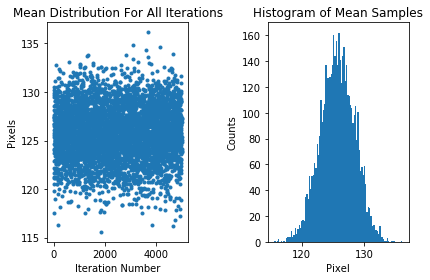

In [39]:
fig, axs = plt.subplots(nrows=1, ncols=2)
ax = axs[0]
ax1= axs[1]

ax.plot(xmc_mean, marker='.', linewidth=0)
ax1.hist(xmc_mean, bins=100)
#ax1.xaxis.set_ticks(np.arange(263, 263.7, 0.2))


ax1.set_xlabel("Pixel")
ax1.set_ylabel("Counts")
ax1.set_title("Histogram of Mean Samples")
ax.set_ylabel("Pixels")
ax.set_xlabel("Iteration Number")
ax.set_title("Mean Distribution For All Iterations")

plt.tight_layout()
#plt.savefig("x_mean_hist", dpi = 300)

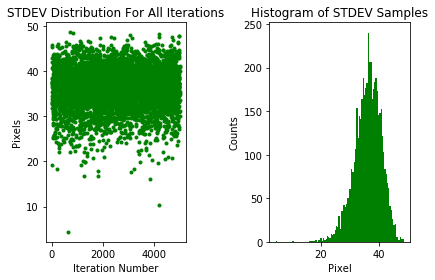

In [40]:
fig, axs = plt.subplots(nrows=1, ncols=2)
ax = axs[0]
ax1= axs[1]

ax.plot(xmc_std, marker='.', linewidth=0, color='g')
ax1.hist(xmc_std, bins=100, color='g')
#ax1.xaxis.set_ticks(np.arange(263, 263.7, 0.2))


ax1.set_xlabel("Pixel")
ax1.set_ylabel("Counts")
ax1.set_title("Histogram of STDEV Samples")
ax.set_ylabel("Pixels")
ax.set_xlabel("Iteration Number")
ax.set_title("STDEV Distribution For All Iterations")

plt.tight_layout()
plt.savefig("x_std_hist", dpi = 300)

P.S. 5 mm is 41 pixels

# Results from all images

In [106]:
stats = pd.read_csv("data_mean_stdev_pix.txt", sep=' ', header= None)
stats.columns= ["name", "x_mean", "x_mean_std", "x_std_mean", "x_std_std", "y_mean", "y_mean_std", "y_std_mean", "y_std_std"]

stats_nO = pd.read_csv("runs_30_36_9_23_43_noOffset.txt", sep=' ', header= None)
stats_nO.columns= ["name", "x_mean", "x_mean_std", "x_std_mean", "x_std_std", "y_mean", "y_mean_std", "y_std_mean", "y_std_std"]


In [108]:
stats_nO["y_mean"]

0    102.144062
1    100.003614
2    104.962250
3    107.295563
4    103.663287
Name: y_mean, dtype: float64

In [109]:
stats["y_mean"][30-6]= stats_nO["y_mean"][0]
stats["y_mean"][36-6]= stats_nO["y_mean"][1]
stats["y_mean"][9-6]= stats_nO["y_mean"][2]

print(stats["y_mean"][30-6])
print(stats["y_mean"][36-6])
print(stats["y_mean"][9-6])
#print(stats["y_mean"][23-6])
#print(stats["y_mean"][43-6])

102.14406240409369
100.00361403470741
104.96224956725972


/home/sara/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.
/home/sara/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  
/home/sara/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [86]:
x_pics =  np.arange(6,56)

Text(0.5, 1.0, 'Mean')

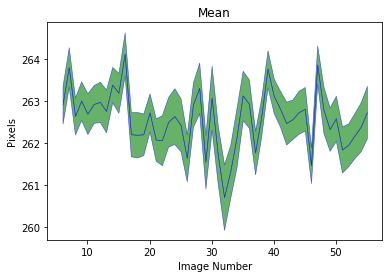

In [73]:
#plt.figure(figsize=(12,8))
plt.fill_between(x_pics, stats['x_mean'],stats['x_mean']+stats["x_mean_std"], alpha=0.6, edgecolor='b', facecolor='g', linewidth=0.6, antialiased=True)           
plt.fill_between(x_pics, stats['x_mean'],stats['x_mean']-stats["x_mean_std"], alpha=0.6, edgecolor='b', facecolor='g', linewidth=0.6, antialiased=True)

plt.xlabel("Image Number")
plt.ylabel("Pixels")
plt.title("Mean")

#plt.savefig("mean_images", dpi = 300)

Text(0.5, 1.0, 'Mean')

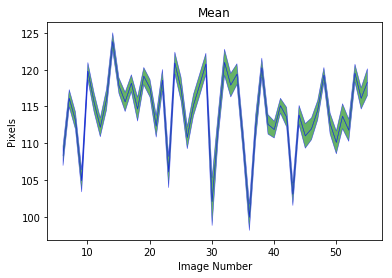

In [102]:
#plt.figure(figsize=(12,8))
plt.fill_between(x_pics, stats['y_mean'],stats['y_mean']+stats["y_mean_std"], alpha=0.6, edgecolor='b', facecolor='g', linewidth=0.6, antialiased=True)           
plt.fill_between(x_pics, stats['y_mean'],stats['y_mean']-stats["y_mean_std"], alpha=0.6, edgecolor='b', facecolor='g', linewidth=0.6, antialiased=True)

plt.xlabel("Image Number")
plt.ylabel("Pixels")
plt.title("Mean")

#plt.savefig("mean_images", dpi = 300)

Text(0, 0.5, 'Pixels')

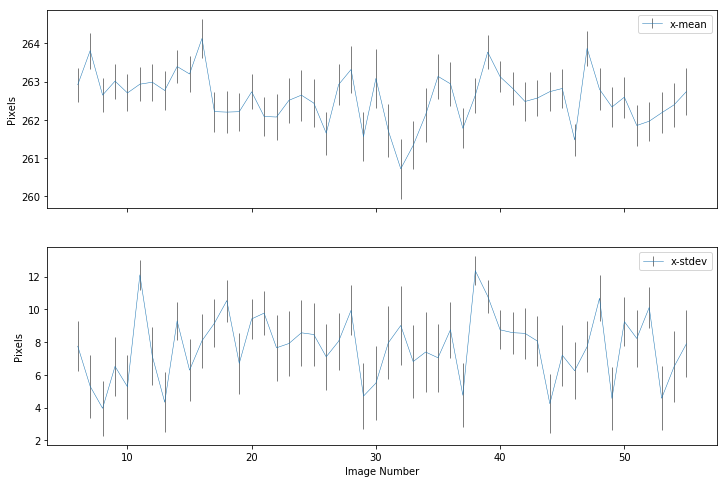

In [104]:

fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True,figsize=(12,8))
ax = axs[0]
ax1= axs[1]

ax.errorbar(x_pics, stats['x_mean'], yerr =stats["x_mean_std"], linewidth=0.5, ecolor='black', capthick=2, label="x-mean")
ax.legend()

ax1.errorbar(x_pics, stats['x_std_mean'], yerr = stats["x_std_std"],linewidth=0.5, ecolor='black', capthick=2, label='x-stdev')
ax1.legend()

ax1.set_xlabel("Image Number")
ax1.set_ylabel("Pixels")
ax.set_ylabel("Pixels")

#plt.savefig("x_mean_stdev_allim", dpi = 300)

Text(0, 0.5, 'Pixels')

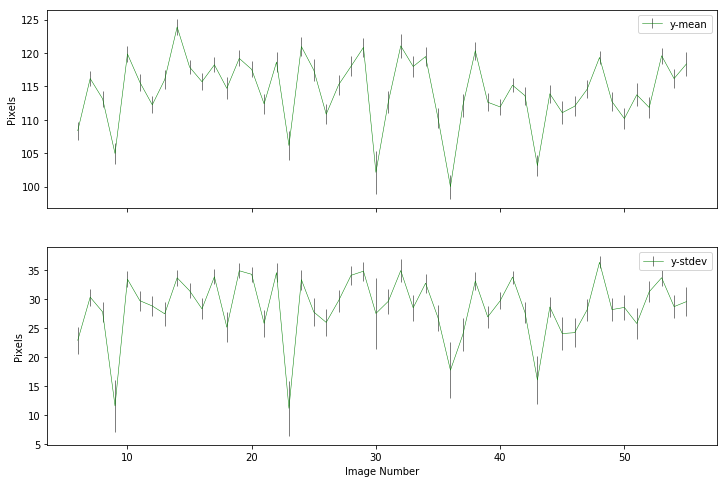

In [110]:

fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(12,8))
ax = axs[0]
ax1= axs[1]

ax.errorbar(x_pics, stats['y_mean'], yerr = stats['y_mean_std'], linewidth=0.5, ecolor='black', color = 'g', capthick=2, label="y-mean")
ax.legend()
ax.locator_params(nbins=6)

ax1.errorbar(x_pics, stats['y_std_mean'], yerr = stats['y_std_std'],linewidth=0.5, ecolor='black', color = 'g', capthick=2, label='y-stdev')
ax1.legend()

ax1.set_xlabel("Image Number")
ax1.set_ylabel("Pixels")
ax.set_ylabel("Pixels")

#plt.savefig("y_mean_stdev_allim_wErr", dpi = 300)

In [96]:
print("Max x: ",np.max(stats['x_mean']), "Min x: ", np.min(stats['x_mean']))
print("Max y: ",np.max(stats['y_mean']), "Min x: ", np.min(stats['y_mean']))

Max x:  264.1261522715013 Min x:  260.7185494796305
Max y:  123.87912357543017 Min x:  100.00361403470741


In [97]:
print("X range in  mm ", (np.max(stats['x_mean']) - np.min(stats['x_mean']))*5/41)
print("Y range in  mm ", (np.max(stats['y_mean']) - np.min(stats['y_mean']))*5/41)

X range in  mm  0.4155613160818084
Y range in  mm  2.91164750496619


In [98]:
print("Max x: ",np.max(stats['x_std_mean']), "Min x: ", np.min(stats['x_std_mean']))
print("Max y: ",np.max(stats['y_std_mean']), "Min x: ", np.min(stats['y_std_mean']))

Max x:  12.355327285472503 Min x:  3.961589123927285
Max y:  36.33071593474771 Min x:  11.182180053056983


In [99]:
print("X size in  mm ", (np.max(stats['x_std_mean'])*2)*5/41)
print("Y size in  mm ", (np.max(stats['y_std_mean'])*2)*5/41)

X size in  mm  3.0134944598713425
Y size in  mm  8.861150227987245


In [100]:
print("fraction of x spot size in movement: ", 0.41/3*100, "%")

fraction of x spot size in movement:  13.666666666666666 %


In [101]:
print("fraction of y spot size in movement: ", 2.9/8.86*100, "%")

fraction of y spot size in movement:  32.731376975169304 %
